<a href="https://colab.research.google.com/github/matteogolfarelli/DataCentricAI/blob/main/Data%20Preparation/Forecast_SalesPRice_with_missing_data_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [23]:
import pandas as pd

dataset_url = 'https://raw.githubusercontent.com/matteogolfarelli/DataCentricAI/main/Data%20Preparation/ames_housing_data_hard.csv'

try:
    df = pd.read_csv(dataset_url)
    print("Dataset loaded successfully from URL.")
except Exception as e:
    print(f"Error loading dataset from URL: {e}")
    df = None

# Display the first 5 rows of the DataFrame
if df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

Dataset loaded successfully from URL.

First 5 rows of the dataset:


,MS Zoning,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
0,RL,1960.0,6.0,5,31770,528.0,0,3,1.0,7,215000
1,RH,1961.0,5.0,6,11622,730.0,0,2,NaN,5,105000
2,RL,1958.0,6.0,6,14267,312.0,0,3,1.0,6,172000
3,RL,1968.0,7.0,5,11160,522.0,0,3,NaN,8,244000
4,RL,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900


### Dataset Description

Let's get a general overview of the dataset, including data types, non-null values, and memory usage, followed by descriptive statistics for numerical columns.

In [24]:
if df is not None:
    print("\nDataset Information:")
    df.info()

    print("\nDescriptive Statistics:")
    display(df.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2929 entries, 0 to 2928
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MS Zoning      2929 non-null   object 
 1   Year Built     2429 non-null   float64
 2   Overall Qual   2717 non-null   float64
 3   Overall Cond   2929 non-null   int64  
 4   Lot Area       2929 non-null   int64  
 5   Garage Area    2929 non-null   float64
 6   Pool Area      2929 non-null   int64  
 7   Bedroom AbvGr  2929 non-null   int64  
 8   Full Bath      2229 non-null   float64
 9   TotRms AbvGrd  2929 non-null   int64  
 10  SalePrice      2929 non-null   int64  
dtypes: float64(4), int64(6), object(1)
memory usage: 251.8+ KB

Descriptive Statistics:


,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2429.000000,2717.000000,2929.000000,2929.000000,2929.000000,2929.000000,2929.000000,2229.000000,2929.000000,2929.000000
mean,1971.503088,6.160839,5.562991,10148.293274,472.819734,2.244111,2.854216,1.576492,6.443155,180806.263913
std,30.238367,1.396228,1.111697,7881.337623,215.046549,35.603235,0.827868,0.559000,1.573212,79898.423323
min,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,1954.000000,5.000000,5.000000,7440.000000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1973.000000,6.000000,5.000000,9439.000000,480.000000,0.000000,3.000000,2.000000,6.000000,160000.000000
75%,2001.000000,7.000000,6.000000,11556.000000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


### Missing Value Analysis

Now, let's analyze the missing values in the dataset. This will show us which columns have missing data and how many.

In [25]:
if df is not None:
    missing_values = df.isnull().sum()
    missing_percentage = (df.isnull().sum() / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Count': missing_values, 'Missing Percentage': missing_percentage})

    print("\nMissing values in each column:")
    # Filter to show only columns with missing values and sort them
    display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

    if missing_df['Missing Count'].sum() == 0:
        print("No missing values found in the dataset.")


Missing values in each column:


,Missing Count,Missing Percentage
Full Bath,700,23.898942
Year Built,500,17.070673
Overall Qual,212,7.237965


### Bivariate Analysis of Missing 'Full Bath' Values

Let's investigate if the missing values in the 'Full Bath' column are related to other attributes in the dataset. We'll create a new indicator column for missing 'Full Bath' and visualize its relationship with other features.

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Create a boolean column indicating if 'Full Bath' is missing
    df['is_full_bath_missing'] = df['Full Bath'].isnull()
    print("Added 'is_full_bath_missing' column to the DataFrame.")
    display(df[['Full Bath', 'is_full_bath_missing']].head())
else:
    print("DataFrame 'df' is not available.")

Added 'is_full_bath_missing' column to the DataFrame.


,Full Bath,is_full_bath_missing
0,1.0,False
1,NaN,True
2,1.0,False
3,NaN,True
4,2.0,False


#### Missing 'Full Bath' by 'MS Zoning' (Categorical Feature)

We'll use a bar chart to count the number of missing 'Full Bath' values for each category within the 'MS Zoning' column.

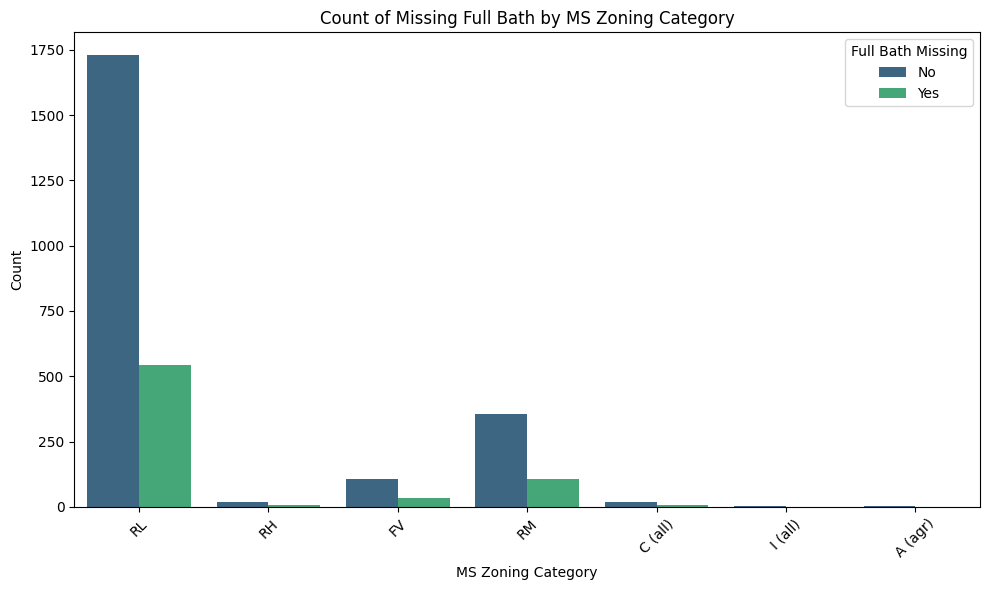

In [27]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.countplot(x='MS Zoning', hue='is_full_bath_missing', data=df, palette='viridis')
    plt.title('Count of Missing Full Bath by MS Zoning Category')
    plt.xlabel('MS Zoning Category')
    plt.ylabel('Count')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Full Bath' and 'Lot Area' (Numerical Feature)

For numerical features like 'Lot Area', a direct bar chart of missing counts isn't ideal. Instead, we'll visualize the distribution of 'Lot Area' for rows where 'Full Bath' is missing versus where it's present, using Kernel Density Estimate (KDE) plots. This helps us see if 'Full Bath' tends to be missing for specific 'Lot Area' ranges.

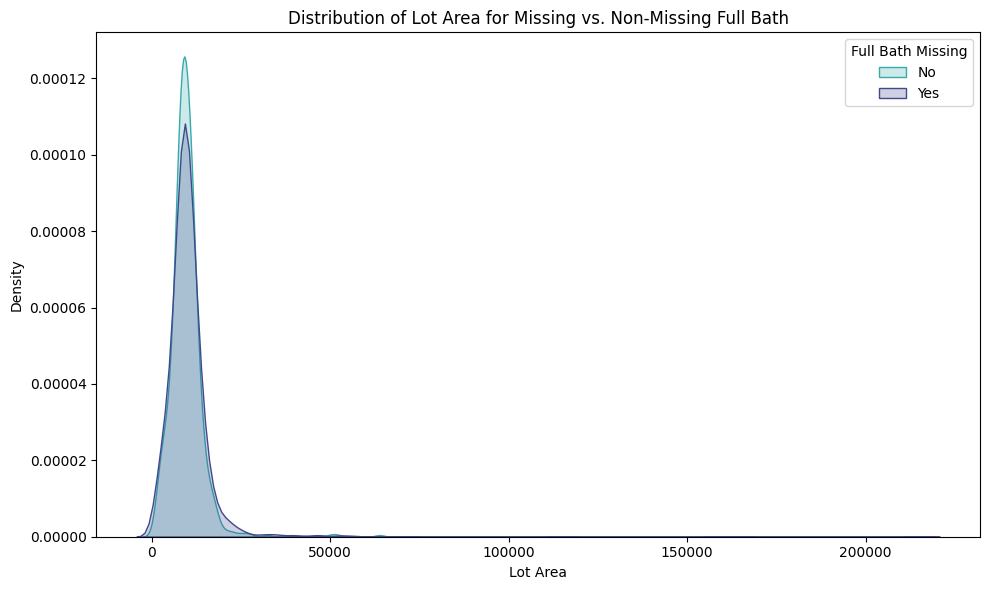

In [28]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Lot Area', hue='is_full_bath_missing', fill=True, common_norm=False, palette='mako')
    plt.title('Distribution of Lot Area for Missing vs. Non-Missing Full Bath')
    plt.xlabel('Lot Area')
    plt.ylabel('Density')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

#### Missing 'Full Bath' and 'Year Built' (Numerical Feature)

Similarly, let's look at the distribution of 'Year Built' for rows with and without missing 'Full Bath' values.

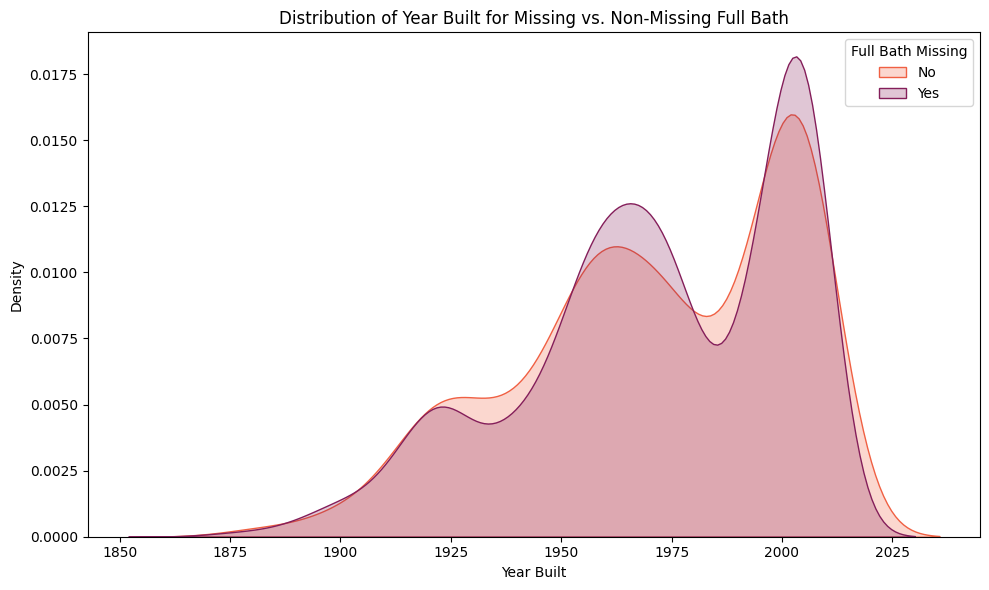

In [29]:
if df is not None:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=df, x='Year Built', hue='is_full_bath_missing', fill=True, common_norm=False, palette='rocket')
    plt.title('Distribution of Year Built for Missing vs. Non-Missing Full Bath')
    plt.xlabel('Year Built')
    plt.ylabel('Density')
    plt.legend(title='Full Bath Missing', labels=['No', 'Yes'])
    plt.tight_layout()
    plt.show()
else:
    print("DataFrame 'df' is not available.")

In [30]:
display(df)

,MS Zoning,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,is_full_bath_missing
0,RL,1960.0,6.0,5,31770,528.0,0,3,1.0,7,215000,False
1,RH,1961.0,5.0,6,11622,730.0,0,2,NaN,5,105000,True
2,RL,1958.0,6.0,6,14267,312.0,0,3,1.0,6,172000,False
3,RL,1968.0,7.0,5,11160,522.0,0,3,NaN,8,244000,True
4,RL,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900,False
...,...,...,...,...,...,...,...,...,...,...,...,...
2924,RL,1984.0,6.0,6,7937,588.0,0,3,1.0,6,142500,False
2925,RL,1983.0,5.0,5,8885,484.0,0,2,1.0,5,131000,False
2926,RL,1992.0,NaN,5,10441,0.0,0,3,1.0,6,132000,False
2927,RL,1974.0,NaN,5,10010,418.0,0,2,NaN,6,170000,True


### Pearson Correlation Matrix

Let's compute the Pearson correlation matrix for the numerical attributes in the dataset to understand the relationships between them. A heatmap will be used for visualization.

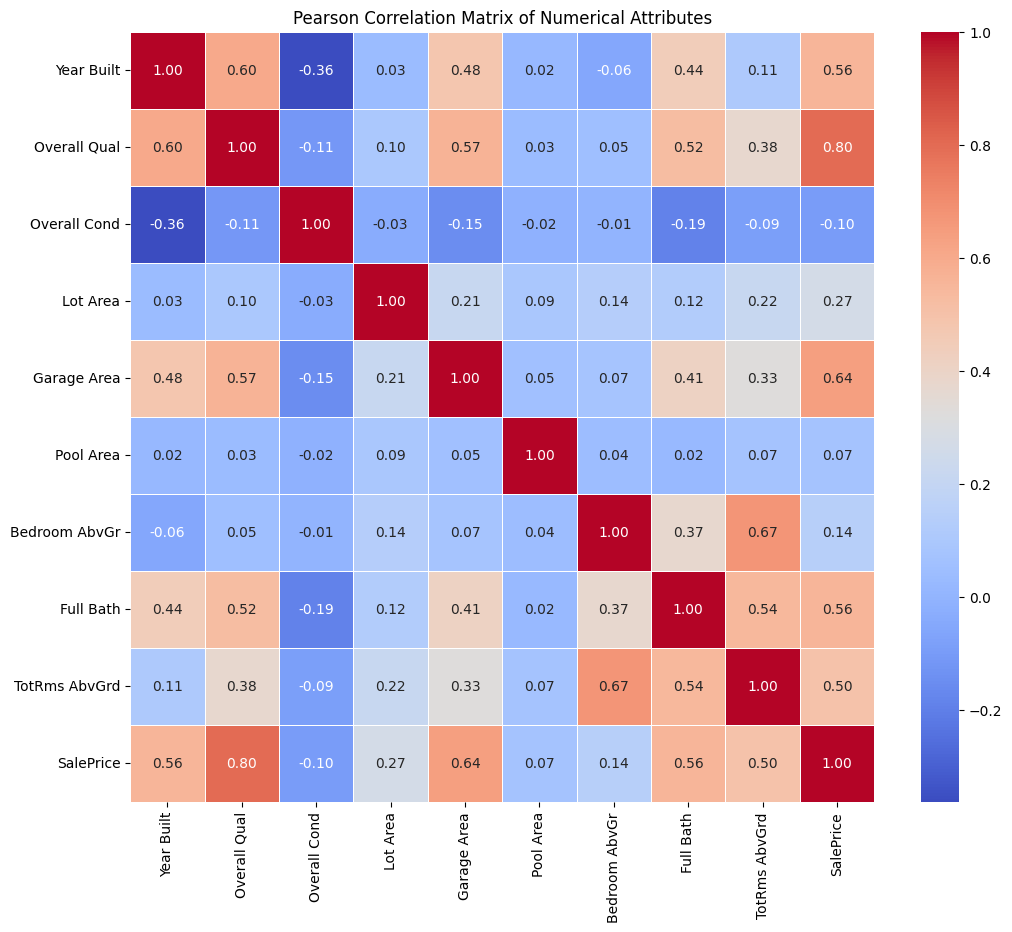

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

if df is not None:
    # Select only numerical columns for correlation calculation
    numerical_df = df.select_dtypes(include=['int64', 'float64'])

    # Drop the 'Order' column if it exists, as it's an identifier
    if 'Order' in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=['Order'])

    # Also drop the 'is_full_bath_missing' column if it exists, as it's an indicator variable
    if 'is_full_bath_missing' in numerical_df.columns:
        numerical_df = numerical_df.drop(columns=['is_full_bath_missing'])

    # Calculate the Pearson correlation matrix
    correlation_matrix = numerical_df.corr(method='pearson')

    # Plot the heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Matrix of Numerical Attributes')
    plt.show()
else:
    print("DataFrame 'df' is not available to calculate correlation matrix.")

### Data Preprocessing for Model Training

We will begin by one-hot encoding all categorical features. Then, we will address missing numerical values using a Random Forest-based imputation method. This involves iteratively training a Random Forest model to predict missing values in one column based on the non-missing values in other columns. Finally, we will drop the `Order` and `is_full_bath_missing` columns.

In [37]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if df is not None:
    # Create a copy to avoid modifying the original DataFrame directly
    df_processed = df.copy()

    # Drop the 'is_full_bath_missing' as it's an indicator
    if 'is_full_bath_missing' in df_processed.columns:
        df_processed = df_processed.drop(columns=['is_full_bath_missing'])

    # Identify all categorical columns for one-hot encoding
    categorical_cols = df_processed.select_dtypes(include=['object']).columns
    if len(categorical_cols) > 0:
        df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)
        print(f"One-hot encoded {len(categorical_cols)} categorical columns.")
    else:
        df_encoded = df_processed
        print("No categorical columns to encode.")

    print("Shape of DataFrame after one-hot encoding:", df_encoded.shape)
    display(df_encoded.head())


One-hot encoded 1 categorical columns.
Shape of DataFrame after one-hot encoding: (2929, 16)


,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1960.0,6.0,5,31770,528.0,0,3,1.0,7,215000,False,False,False,False,True,False
1,1961.0,5.0,6,11622,730.0,0,2,NaN,5,105000,False,False,False,True,False,False
2,1958.0,6.0,6,14267,312.0,0,3,1.0,6,172000,False,False,False,False,True,False
3,1968.0,7.0,5,11160,522.0,0,3,NaN,8,244000,False,False,False,False,True,False
4,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900,False,False,False,False,True,False


In [36]:

    # --- Random Forest Imputation ---
    print("\nStarting Random Forest imputation for missing numerical values...")
    df_imputed = df_encoded.copy()

    # Identify numerical columns with missing values
    cols_with_missing = df_imputed.select_dtypes(include=['int64', 'float64']).columns[df_imputed.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()

    # Exclude 'SalePrice' from imputation if it's in cols_with_missing (it's our target)
    if 'SalePrice' in cols_with_missing:
        cols_with_missing.remove('SalePrice')

    # Iterate and impute each column with missing values
    for col in cols_with_missing:
        print(f"  Imputing missing values in column: '{col}'")
        # Separate data into observed and missing for the current column
        df_observed = df_imputed.dropna(subset=[col])
        df_missing = df_imputed[df_imputed[col].isnull()]

        if not df_missing.empty:
            # Features to train the imputer (all other columns without missing values)
            features_for_imputation = [c for c in df_observed.columns if c != col and df_observed[c].isnull().sum() == 0]

            # If there are no features to train, fall back to mean imputation for this column
            if not features_for_imputation:
                mean_val = df_observed[col].mean()
                df_imputed.loc[df_imputed[col].isnull(), col] = mean_val
                print(f"    (Falling back to mean imputation for '{col}' due to no clean features: {mean_val:.2f})")
                continue

            X_impute_train = df_observed[features_for_imputation]
            y_impute_train = df_observed[col]
            X_impute_predict = df_missing[features_for_imputation]

            # Handle potential missing values in features_for_imputation for X_impute_predict (shouldn't happen if selected properly)
            # If there are still missing values in the imputation features, drop those rows for prediction only.
            rows_to_drop_predict = X_impute_predict.isnull().any(axis=1)
            if rows_to_drop_predict.any():
                print(f"    Warning: Dropping {rows_to_drop_predict.sum()} rows for predicting '{col}' due to missing values in imputation features.")
                X_impute_predict = X_impute_predict[~rows_to_drop_predict]
                df_missing_subset = df_missing[~rows_to_drop_predict]
            else:
                df_missing_subset = df_missing

            if not X_impute_predict.empty:
                rf_imputer = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
                rf_imputer.fit(X_impute_train, y_impute_train)
                predicted_values = rf_imputer.predict(X_impute_predict)
                df_imputed.loc[df_missing_subset.index, col] = predicted_values
                print(f"    Successfully imputed {len(predicted_values)} values for '{col}'.")
            else:
                print(f"    No rows left to predict for '{col}' after handling missing features.")
        else:
            print(f"    No missing values in '{col}' to impute.")

    # Verify no more missing values
    if df_imputed.isnull().sum().sum() == 0:
        print("\nAll missing values handled after Random Forest imputation.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        display(df_imputed.isnull().sum()[df_imputed.isnull().sum() > 0])

    df_cleaned = df_imputed # Final preprocessed DataFrame
    print("Shape of DataFrame after full preprocessing:", df_cleaned.shape)
    display(df_cleaned.head())


Starting Random Forest imputation for missing numerical values...
  Imputing missing values in column: 'Year Built'
    Successfully imputed 500 values for 'Year Built'.
  Imputing missing values in column: 'Overall Qual'
    Successfully imputed 212 values for 'Overall Qual'.
  Imputing missing values in column: 'Full Bath'
    Successfully imputed 700 values for 'Full Bath'.

All missing values handled after Random Forest imputation.
Shape of DataFrame after full preprocessing: (2929, 16)


,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1960.0,6.0,5,31770,528.0,0,3,1.00,7,215000,False,False,False,False,True,False
1,1961.0,5.0,6,11622,730.0,0,2,1.04,5,105000,False,False,False,True,False,False
2,1958.0,6.0,6,14267,312.0,0,3,1.00,6,172000,False,False,False,False,True,False
3,1968.0,7.0,5,11160,522.0,0,3,1.98,8,244000,False,False,False,False,True,False
4,1997.0,5.0,5,13830,482.0,0,3,2.00,6,189900,False,False,False,False,True,False


### Random Forest Model Training

Now, we will train a Random Forest Regressor model to forecast 'SalePrice' using the preprocessed data. We will split the data into training and testing sets to evaluate the model's performance.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

if 'df_cleaned' in locals() and df_cleaned is not None:
    # Define features (X) and target (y)
    X = df_cleaned.drop('SalePrice', axis=1)
    y = df_cleaned['SalePrice']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Data split into training and testing sets.")
    print(f"Training features shape: {X_train.shape}")
    print(f"Testing features shape: {X_test.shape}")
else:
    print("Cleaned DataFrame 'df_cleaned' is not available for model training.")

Data split into training and testing sets.
Training features shape: (2344, 15)
Testing features shape: (586, 15)


In [13]:
if 'X_train' in locals() and 'y_train' in locals():
    # Initialize and train the Random Forest Regressor model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    print("Random Forest Regressor model trained successfully.")
else:
    print("Training data is not available to train the model.")

Random Forest Regressor model trained successfully.


### Model Evaluation

Let's evaluate the performance of the trained Random Forest model on the test set using R-squared and Mean Squared Error.

In [14]:
if 'rf_model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"R-squared: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.2f}")

    # Display feature importances (optional but good for understanding the model)
    feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    print("\nTop 10 Feature Importances:")
    display(feature_importances.nlargest(10))
else:
    print("Model or test data is not available for evaluation.")

R-squared: 0.8586
Mean Squared Error: 1133344872.17

Top 10 Feature Importances:


,0
Overall Qual,0.630287
Full Bath,0.105288
Lot Area,0.087240
Garage Area,0.075779
Year Built,0.035604
TotRms AbvGrd,0.026766
Bedroom AbvGr,0.013622
Overall Cond,0.011017
Pool Area,0.005639
MS Zoning_RM,0.003897


### Data Preprocessing for Model Training

Following the updated instructions, we will first impute missing numerical values with the mean of their respective columns. Then, we will one-hot encode the 'MS Zoning' categorical feature. We will also drop the `Order` column as it is an identifier and the `is_full_bath_missing` column as it was created for analysis and not for model features.

In [15]:
import pandas as pd

if df is not None:
    # Create a copy to avoid modifying the original DataFrame directly for imputation
    df_processed = df.copy()

    # Drop the 'Order' column as it's an identifier and 'is_full_bath_missing' as it's an indicator
    if 'Order' in df_processed.columns:
        df_processed = df_processed.drop(columns=['Order'])
    if 'is_full_bath_missing' in df_processed.columns:
        df_processed = df_processed.drop(columns=['is_full_bath_missing'])

    # Impute missing numerical values with the mean of their column
    numerical_cols = df_processed.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_cols:
        if df_processed[col].isnull().any():
            mean_value = df_processed[col].mean()
            df_processed[col] = df_processed[col].fillna(mean_value)
            print(f"Imputed missing values in '{col}' with its mean: {mean_value:.2f}")

    # One-hot encode 'MS Zoning' column
    if 'MS Zoning' in df_processed.columns:
        df_encoded = pd.get_dummies(df_processed, columns=['MS Zoning'], drop_first=True)
        print("One-hot encoded 'MS Zoning' column.")
    else:
        df_encoded = df_processed # If MS Zoning is not present or already handled

    # Verify no more missing values
    if df_encoded.isnull().sum().sum() == 0:
        print("All missing values handled.")
    else:
        print("Warning: Some missing values still exist after processing.")
        display(df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0])

    df_cleaned = df_encoded # Rename for consistency with previous steps
    print("Shape of DataFrame after preprocessing:", df_cleaned.shape)
    display(df_cleaned.head())
else:
    print("DataFrame 'df' is not available for preprocessing.")

Imputed missing values in 'Year Built' with its mean: 1971.51
Imputed missing values in 'Overall Qual' with its mean: 6.16
Imputed missing values in 'Garage Area' with its mean: 472.82
Imputed missing values in 'Full Bath' with its mean: 1.56
One-hot encoded 'MS Zoning' column.
All missing values handled.
Shape of DataFrame after preprocessing: (2930, 16)


,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1960.0,6.000000,5,31770,528.0,0,3,1.56278,7,215000,False,False,False,False,True,False
1,1961.0,5.000000,6,11622,730.0,0,2,1.00000,5,105000,False,False,False,True,False,False
2,1958.0,6.160044,6,14267,312.0,0,3,1.56278,6,172000,False,False,False,False,True,False
3,1968.0,7.000000,5,11160,522.0,0,3,2.00000,8,244000,False,False,False,False,True,False
4,1997.0,5.000000,5,13830,482.0,0,3,2.00000,6,189900,False,False,False,False,True,False


In [16]:
    print("\nDescriptive Statistics:")
    display(df.describe())


Descriptive Statistics:


,Order,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice
count,2930.00000,2430.000000,2718.000000,2930.000000,2930.000000,2929.000000,2930.000000,2930.000000,2230.000000,2930.000000,2930.000000
mean,1465.50000,1971.506173,6.160044,5.563140,10147.921843,472.819734,2.243345,2.854266,1.562780,6.443003,180796.060068
std,845.96247,30.062453,1.397113,1.111537,7880.017759,215.046549,35.597181,0.827731,0.550994,1.572964,79886.692357
min,1.00000,1872.000000,1.000000,1.000000,1300.000000,0.000000,0.000000,0.000000,0.000000,2.000000,12789.000000
25%,733.25000,1954.000000,5.000000,5.000000,7440.250000,320.000000,0.000000,2.000000,1.000000,5.000000,129500.000000
50%,1465.50000,1973.000000,6.000000,5.000000,9436.500000,480.000000,0.000000,3.000000,2.000000,6.000000,160000.000000
75%,2197.75000,2001.000000,7.000000,6.000000,11555.250000,576.000000,0.000000,3.000000,2.000000,7.000000,213500.000000
max,2930.00000,2010.000000,10.000000,9.000000,215245.000000,1488.000000,800.000000,8.000000,4.000000,15.000000,755000.000000


### Random Forest Model Training

Now, we will train a Random Forest Regressor model to forecast 'SalePrice' using the preprocessed data. We will split the data into training and testing sets to evaluate the model's performance.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error

if 'df_cleaned' in locals() and df_cleaned is not None:
    # Define features (X) and target (y)
    X = df_cleaned.drop('SalePrice', axis=1)
    y = df_cleaned['SalePrice']

    # Split the data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    print("Data split into training and testing sets.")
    print(f"Training features shape: {X_train.shape}")
    print(f"Testing features shape: {X_test.shape}")
else:
    print("Cleaned DataFrame 'df_cleaned' is not available for model training.")

Data split into training and testing sets.
Training features shape: (2344, 15)
Testing features shape: (586, 15)


In [18]:
if 'X_train' in locals() and 'y_train' in locals():
    # Initialize and train the Random Forest Regressor model
    rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf_model.fit(X_train, y_train)
    print("Random Forest Regressor model trained successfully.")
else:
    print("Training data is not available to train the model.")

Random Forest Regressor model trained successfully.


### Model Evaluation

Let's evaluate the performance of the trained Random Forest model on the test set using R-squared and Mean Squared Error.

In [19]:
if 'rf_model' in locals() and 'X_test' in locals() and 'y_test' in locals():
    # Make predictions on the test set
    y_pred = rf_model.predict(X_test)

    # Evaluate the model
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"R-squared: {r2:.4f}")
    print(f"Mean Squared Error: {mse:.2f}")

    # Display feature importances (optional but good for understanding the model)
    feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
    print("\nTop 10 Feature Importances:")
    display(feature_importances.nlargest(10))
else:
    print("Model or test data is not available for evaluation.")

R-squared: 0.8082
Mean Squared Error: 1537710613.29

Top 10 Feature Importances:


,0
Overall Qual,0.624623
Garage Area,0.117680
Lot Area,0.097684
TotRms AbvGrd,0.044293
Year Built,0.037323
Full Bath,0.023038
Bedroom AbvGr,0.017719
Overall Cond,0.017322
Pool Area,0.007581
MS Zoning_RL,0.006777


### XGBoost Regressor Training (without explicit imputation)

In [56]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_encoded' in locals() and df_encoded is not None:
    # Define features (X) and target (y) from df_encoded
    # XGBoost can handle NaNs directly, so no explicit imputation is needed here.
    X_xgb = df_encoded.drop('SalePrice', axis=1)
    y_xgb = df_encoded['SalePrice']

    # Split the data into training and testing sets
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

    print("Data split into training and testing sets for XGBoost.")
    print(f"Training features shape: {X_train_xgb.shape}")
    print(f"Testing features shape: {X_test_xgb.shape}")

    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_xgb)

    # Evaluate the model
    r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_xgb.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_encoded' is not available for XGBoost model training.")

Data split into training and testing sets for XGBoost.
Training features shape: (2343, 15)
Testing features shape: (586, 15)
XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8481
XGBoost Mean Squared Error: 1144886656.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.543187
MS Zoning_RM,0.075518
Pool Area,0.064939
MS Zoning_RL,0.056631
TotRms AbvGrd,0.042506
Garage Area,0.039694
Full Bath,0.037139
Lot Area,0.032034
Bedroom AbvGr,0.029192
Overall Cond,0.025885


### Mean Imputation on `df_encoded`

Now, let's perform mean imputation on the `df_encoded` DataFrame. This will fill any remaining `NaN` values in numerical columns with the mean of that column. The result will be stored in a new DataFrame named `df_mean`.

In [57]:
if 'df_encoded' in locals() and df_encoded is not None:
    df_mean = df_encoded.copy()

    numerical_cols = df_mean.select_dtypes(include=['int64', 'float64']).columns

    for col in numerical_cols:
        if df_mean[col].isnull().any():
            mean_value = df_mean[col].mean()
            df_mean[col] = df_mean[col].fillna(mean_value)
            print(f"Imputed missing values in '{col}' with its mean: {mean_value:.2f}")

    if df_mean.isnull().sum().sum() == 0:
        print("\nAll missing values handled in df_mean after mean imputation.")
    else:
        print("\nWarning: Some missing values still exist in df_mean. Details:")
        display(df_mean.isnull().sum()[df_mean.isnull().sum() > 0])

    print("\nShape of df_mean after mean imputation:", df_mean.shape)
    display(df_mean.head())
else:
    print("DataFrame 'df_encoded' is not available for mean imputation.")

Imputed missing values in 'Year Built' with its mean: 1971.50
Imputed missing values in 'Overall Qual' with its mean: 6.16
Imputed missing values in 'Full Bath' with its mean: 1.58

All missing values handled in df_mean after mean imputation.

Shape of df_mean after mean imputation: (2929, 16)


,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1960.0,6.0,5,31770,528.0,0,3,1.000000,7,215000,False,False,False,False,True,False
1,1961.0,5.0,6,11622,730.0,0,2,1.576492,5,105000,False,False,False,True,False,False
2,1958.0,6.0,6,14267,312.0,0,3,1.000000,6,172000,False,False,False,False,True,False
3,1968.0,7.0,5,11160,522.0,0,3,1.576492,8,244000,False,False,False,False,True,False
4,1997.0,5.0,5,13830,482.0,0,3,2.000000,6,189900,False,False,False,False,True,False


In [58]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_mean' in locals() and df_mean is not None:
    # Define features (X) and target (y) from df_mean
    # XGBoost can handle NaNs directly, so no explicit imputation is needed here.
    X_xgb = df_mean.drop('SalePrice', axis=1)
    y_xgb = df_mean['SalePrice']

    # Split the data into training and testing sets
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

    print("Data split into training and testing sets for XGBoost.")
    print(f"Training features shape: {X_train_xgb.shape}")
    print(f"Testing features shape: {X_test_xgb.shape}")

    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_xgb)

    # Evaluate the model
    r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_xgb.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_rf' is not available for XGBoost model training.")

Data split into training and testing sets for XGBoost.
Training features shape: (2343, 15)
Testing features shape: (586, 15)
XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8501
XGBoost Mean Squared Error: 1129617792.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.590558
Full Bath,0.047295
Pool Area,0.046925
TotRms AbvGrd,0.042677
MS Zoning_RM,0.041440
Garage Area,0.039202
MS Zoning_RL,0.038232
Lot Area,0.030943
Bedroom AbvGr,0.030754
MS Zoning_C (all),0.025919


### Random Forest Imputation on `df_encoded`

Let's perform Random Forest imputation on the `df_encoded` DataFrame to handle its missing numerical values. The result will be stored in a new DataFrame named `df_rf`.

In [60]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

if 'df_encoded' in locals() and df_encoded is not None:
    print("\nStarting Random Forest imputation for missing numerical values...")
    df_rf = df_encoded.copy()

    # Identify numerical columns with missing values
    cols_with_missing = df_rf.select_dtypes(include=['int64', 'float64']).columns[df_rf.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()

    # Exclude 'SalePrice' from imputation if it's in cols_with_missing (it's our target)
    if 'SalePrice' in cols_with_missing:
        cols_with_missing.remove('SalePrice')

    # Iterate and impute each column with missing values
    for col in cols_with_missing:
        print(f"  Imputing missing values in column: '{col}'")
        # Separate data into observed and missing for the current column
        df_observed = df_rf.dropna(subset=[col])
        df_missing = df_rf[df_rf[col].isnull()]

        if not df_missing.empty:
            # Features to train the imputer (all other columns without missing values)
            features_for_imputation = [c for c in df_observed.columns if c != col and df_observed[c].isnull().sum() == 0]

            # If there are no features to train, fall back to mean imputation for this column
            if not features_for_imputation:
                mean_val = df_observed[col].mean()
                df_rf.loc[df_rf[col].isnull(), col] = mean_val
                print(f"    (Falling back to mean imputation for '{col}' due to no clean features: {mean_val:.2f})")
                continue

            X_impute_train = df_observed[features_for_imputation]
            y_impute_train = df_observed[col]
            X_impute_predict = df_missing[features_for_imputation]

            # Handle potential missing values in features_for_imputation for X_impute_predict (shouldn't happen if selected properly)
            # If there are still missing values in the imputation features, drop those rows for prediction only.
            rows_to_drop_predict = X_impute_predict.isnull().any(axis=1)
            if rows_to_drop_predict.any():
                print(f"    Warning: Dropping {rows_to_drop_predict.sum()} rows for predicting '{col}' due to missing values in imputation features.")
                X_impute_predict = X_impute_predict[~rows_to_drop_predict]
                df_missing_subset = df_missing[~rows_to_drop_predict]
            else:
                df_missing_subset = df_missing

            if not X_impute_predict.empty:
                rf_imputer = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
                rf_imputer.fit(X_impute_train, y_impute_train)
                predicted_values = rf_imputer.predict(X_impute_predict)
                df_rf.loc[df_missing_subset.index, col] = predicted_values
                print(f"    Successfully imputed {len(predicted_values)} values for '{col}'.")
            else:
                print(f"    No rows left to predict for '{col}' after handling missing features.")
        else:
            print(f"    No missing values in '{col}' to impute.")

    # Verify no more missing values
    if df_rf.isnull().sum().sum() == 0:
        print("\nAll missing values handled after Random Forest imputation.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        display(df_rf.isnull().sum()[df_rf.isnull().sum() > 0])

    print("Shape of DataFrame after Random Forest imputation:", df_rf.shape)
    display(df_rf.head())
else:
    print("DataFrame 'df_encoded' is not available for Random Forest imputation.")


Starting Random Forest imputation for missing numerical values...
  Imputing missing values in column: 'Year Built'
    Successfully imputed 500 values for 'Year Built'.
  Imputing missing values in column: 'Overall Qual'
    Successfully imputed 212 values for 'Overall Qual'.
  Imputing missing values in column: 'Full Bath'
    Successfully imputed 700 values for 'Full Bath'.

All missing values handled after Random Forest imputation.
Shape of DataFrame after Random Forest imputation: (2929, 16)


,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1960.0,6.0,5,31770,528.0,0,3,1.00,7,215000,False,False,False,False,True,False
1,1961.0,5.0,6,11622,730.0,0,2,1.04,5,105000,False,False,False,True,False,False
2,1958.0,6.0,6,14267,312.0,0,3,1.00,6,172000,False,False,False,False,True,False
3,1968.0,7.0,5,11160,522.0,0,3,1.98,8,244000,False,False,False,False,True,False
4,1997.0,5.0,5,13830,482.0,0,3,2.00,6,189900,False,False,False,False,True,False


In [61]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_rf' in locals() and df_rf is not None:
    # Define features (X) and target (y) from df_rf
    # XGBoost can handle NaNs directly, so no explicit imputation is needed here.
    X_xgb = df_rf.drop('SalePrice', axis=1)
    y_xgb = df_rf['SalePrice']

    # Split the data into training and testing sets
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

    print("Data split into training and testing sets for XGBoost.")
    print(f"Training features shape: {X_train_xgb.shape}")
    print(f"Testing features shape: {X_test_xgb.shape}")

    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_xgb)

    # Evaluate the model
    r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_xgb.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_rf' is not available for XGBoost model training.")

Data split into training and testing sets for XGBoost.
Training features shape: (2343, 15)
Testing features shape: (586, 15)
XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8409
XGBoost Mean Squared Error: 1198749824.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.591818
Full Bath,0.087006
MS Zoning_RL,0.053502
MS Zoning_RM,0.042916
Pool Area,0.041918
Garage Area,0.029569
Lot Area,0.027973
Bedroom AbvGr,0.027941
TotRms AbvGrd,0.027742
Overall Cond,0.021772


### K-Nearest Neighbors (KNN) Imputation on `df_encoded`

Let's perform K-Nearest Neighbors (KNN) imputation on the `df_encoded` DataFrame to handle its missing numerical values. This method imputes missing values by finding the `n_neighbors` closest samples in the training set and averaging their values. The result will be stored in a new DataFrame named `df_knn`.

In [62]:
import pandas as pd
from sklearn.impute import KNNImputer

if 'df_encoded' in locals() and df_encoded is not None:
    print("\nStarting K-Nearest Neighbors (KNN) imputation for missing numerical values...")
    df_knn = df_encoded.copy()

    # Identify numerical columns with missing values (excluding SalePrice)
    numerical_cols_with_missing = df_knn.select_dtypes(include=['int64', 'float64']).columns[
        df_knn.select_dtypes(include=['int64', 'float64']).isnull().any()
    ].tolist()

    if 'SalePrice' in numerical_cols_with_missing:
        numerical_cols_with_missing.remove('SalePrice')

    if numerical_cols_with_missing:
        # Initialize KNNImputer
        # n_neighbors is the number of neighboring samples to use for imputation
        imputer = KNNImputer(n_neighbors=5)

        # Apply imputation to the identified columns
        df_knn[numerical_cols_with_missing] = imputer.fit_transform(df_knn[numerical_cols_with_missing])
        print(f"Successfully imputed missing values in columns: {numerical_cols_with_missing}")
    else:
        print("No numerical columns with missing values to impute.")

    # Verify no more missing values (except potentially SalePrice if it was originally missing and excluded from imputation)
    if df_knn.isnull().sum().sum() == 0:
        print("\nAll missing values handled after KNN imputation.")
    else:
        print("\nWarning: Some missing values still exist after processing. Details:")
        display(df_knn.isnull().sum()[df_knn.isnull().sum() > 0])

    print("Shape of DataFrame after KNN imputation:", df_knn.shape)
    display(df_knn.head())
else:
    print("DataFrame 'df_encoded' is not available for KNN imputation.")


Starting K-Nearest Neighbors (KNN) imputation for missing numerical values...
Successfully imputed missing values in columns: ['Year Built', 'Overall Qual', 'Full Bath']

All missing values handled after KNN imputation.
Shape of DataFrame after KNN imputation: (2929, 16)


,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1960.0,6.0,5,31770,528.0,0,3,1.0,7,215000,False,False,False,False,True,False
1,1961.0,5.0,6,11622,730.0,0,2,1.2,5,105000,False,False,False,True,False,False
2,1958.0,6.0,6,14267,312.0,0,3,1.0,6,172000,False,False,False,False,True,False
3,1968.0,7.0,5,11160,522.0,0,3,2.2,8,244000,False,False,False,False,True,False
4,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900,False,False,False,False,True,False


In [63]:
display(df_encoded)

,Year Built,Overall Qual,Overall Cond,Lot Area,Garage Area,Pool Area,Bedroom AbvGr,Full Bath,TotRms AbvGrd,SalePrice,MS Zoning_C (all),MS Zoning_FV,MS Zoning_I (all),MS Zoning_RH,MS Zoning_RL,MS Zoning_RM
0,1960.0,6.0,5,31770,528.0,0,3,1.0,7,215000,False,False,False,False,True,False
1,1961.0,5.0,6,11622,730.0,0,2,NaN,5,105000,False,False,False,True,False,False
2,1958.0,6.0,6,14267,312.0,0,3,1.0,6,172000,False,False,False,False,True,False
3,1968.0,7.0,5,11160,522.0,0,3,NaN,8,244000,False,False,False,False,True,False
4,1997.0,5.0,5,13830,482.0,0,3,2.0,6,189900,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2924,1984.0,6.0,6,7937,588.0,0,3,1.0,6,142500,False,False,False,False,True,False
2925,1983.0,5.0,5,8885,484.0,0,2,1.0,5,131000,False,False,False,False,True,False
2926,1992.0,NaN,5,10441,0.0,0,3,1.0,6,132000,False,False,False,False,True,False
2927,1974.0,NaN,5,10010,418.0,0,2,NaN,6,170000,False,False,False,False,True,False


In [64]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

if 'df_knn' in locals() and df_rf is not None:
    # Define features (X) and target (y) from df_knn
    # XGBoost can handle NaNs directly, so no explicit imputation is needed here.
    X_xgb = df_knn.drop('SalePrice', axis=1)
    y_xgb = df_knn['SalePrice']

    # Split the data into training and testing sets
    X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X_xgb, y_xgb, test_size=0.2, random_state=42)

    print("Data split into training and testing sets for XGBoost.")
    print(f"Training features shape: {X_train_xgb.shape}")
    print(f"Testing features shape: {X_test_xgb.shape}")

    # Initialize and train the XGBoost Regressor model
    # tree_method='hist' for faster training with missing value support
    # n_jobs=-1 to use all available cores
    xgb_model = xgb.XGBRegressor(
        objective='reg:squarederror', # Objective for regression tasks
        n_estimators=100,
        random_state=42,
        n_jobs=-1,
        tree_method='hist' # Enable faster training and native missing value handling
    )
    xgb_model.fit(X_train_xgb, y_train_xgb)
    print("XGBoost Regressor model trained successfully without explicit imputation.")

    # Make predictions on the test set
    y_pred_xgb = xgb_model.predict(X_test_xgb)

    # Evaluate the model
    r2_xgb = r2_score(y_test_xgb, y_pred_xgb)
    mse_xgb = mean_squared_error(y_test_xgb, y_pred_xgb)

    print(f"\nXGBoost R-squared: {r2_xgb:.4f}")
    print(f"XGBoost Mean Squared Error: {mse_xgb:.2f}")

    # Display feature importances
    feature_importances_xgb = pd.Series(xgb_model.feature_importances_, index=X_xgb.columns)
    print("\nTop 10 XGBoost Feature Importances:")
    display(feature_importances_xgb.nlargest(10))
else:
    print("DataFrame 'df_knn' is not available for XGBoost model training.")

Data split into training and testing sets for XGBoost.
Training features shape: (2343, 15)
Testing features shape: (586, 15)
XGBoost Regressor model trained successfully without explicit imputation.

XGBoost R-squared: 0.8509
XGBoost Mean Squared Error: 1123638144.00

Top 10 XGBoost Feature Importances:


,0
Overall Qual,0.612424
Pool Area,0.049916
MS Zoning_RM,0.047717
MS Zoning_RL,0.047690
TotRms AbvGrd,0.036002
Garage Area,0.033820
Full Bath,0.033217
Lot Area,0.027774
Bedroom AbvGr,0.027758
Overall Cond,0.020602
